In [16]:
import pandas as pd

df = pd.read_csv("../data/US-pumpkins.csv")

df.head()
df.tail()

extracted_cols = [
    'Package',
    'Low Price',
    'High Price',
    'Date',
]

# Extract all rows for only the specified columns
pumpkin_data = df.loc[:, extracted_cols]

pumpkin_data = pumpkin_data[pumpkin_data['Package'].str.contains('bushel', case=True, regex=True)]

# Calculate the average price between 'Low Price' and 'High Price'
avg_price_df = (pumpkin_data['Low Price'] + pumpkin_data['High Price']) / 2

# Extract the month from the 'Date' column
month = pd.DatetimeIndex(pumpkin_data['Date']).month

In [17]:
# New DataFrame
new_df = pd.DataFrame({
    'Month': month,
    'Price': avg_price_df,
    'High Price': pumpkin_data['High Price'],
    'Low Price': pumpkin_data['Low Price'],
    'Package': pumpkin_data['Package']
})

new_df.loc[new_df['Package'].str.contains('1 1/9'), 'Price'] = new_df['Price']/(1 + 1/9)

new_df.loc[new_df['Package'].str.contains('1/2'), 'Price'] = new_df['Price']/(1/2)

new_df.head()

,Month,Price,High Price,Low Price,Package
70,9,13.5,15.0,15.0,1 1/9 bushel cartons
71,9,16.2,18.0,18.0,1 1/9 bushel cartons
72,10,16.2,18.0,18.0,1 1/9 bushel cartons
73,10,15.3,17.0,17.0,1 1/9 bushel cartons
74,10,13.5,15.0,15.0,1 1/9 bushel cartons


<Axes: xlabel='Month'>

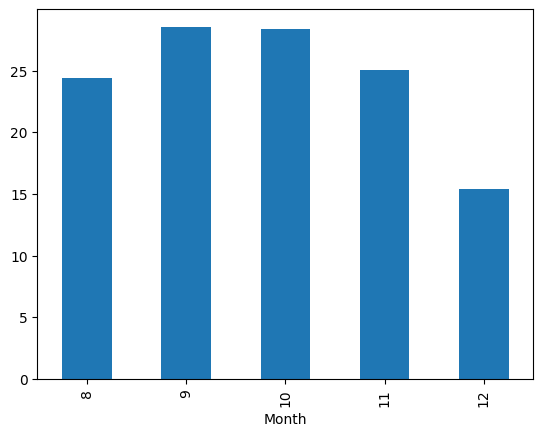

In [20]:
import matplotlib.pyplot as plt

new_df.groupby(["Month"])["Price"].mean().plot(kind='bar')
